Test IX A - Foundation Model for Gravitational Lensing
MAE Pre-training and Fine-tuning for Classification
ML4Sci DeepLense GSoC 2026
by Krishna (Bala Muralikrishna Durukunala)
Robert Morris University - MS Artificial Intelligence

so this is the main test for the foundation model project.
the idea is to first pre-train a Masked Autoencoder on lensing
images without using any labels. then fine-tune it for classification.

MAE works by hiding 75% of the image and making the model
reconstruct the missing parts. to do this well the model needs
to deeply understand the structure of lensing images.
after pretraining the encoder learns really good features which
we can then use for classification with very few labeled samples.

i think this is a really clever idea because labeling scientific
data is expensive and time consuming. so if we can learn good
features without labels that is very useful in practice.
this is similar to how BERT works in NLP - pretrain on unlabeled
text then finetune for specific tasks.

In [3]:
# installing required libraries
!pip install timm einops -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from einops import rearrange

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)
print("torch version:", torch.__version__)

device: cuda
torch version: 2.10.0+cu128


step 1 - loading the dataset

this dataset has 3 classes no_sub cdm and axion
different names from test 1 but same concept
no_sub = no dark matter substructure
cdm = cold dark matter substructure
axion = axion like particle substructure

In [4]:
# mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# unzipping test ix.a dataset
# i renamed it to dataset_ix_a.zip so i dont confuse with test 1
zip_path = '/content/drive/MyDrive/DeepLense/dataset_ix_a.zip'
extract_path = '/content/data/test9a'

os.makedirs(extract_path, exist_ok=True)

print("unzipping please wait...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("done!")

# checking what folders we got
for item in os.listdir(extract_path):
    if '__MACOSX' not in item:
        print(item)

unzipping please wait...
done!
Dataset


In [7]:
# checking inside Dataset folder
dataset_path = '/content/data/test9a/Dataset'

for item in os.listdir(dataset_path):
    if '__MACOSX' not in item and '.DS' not in item:
        print(item)

no_sub
cdm
axion


In [8]:
# setting up paths
data_root = '/content/data/test9a/Dataset'
class_names = ['no_sub', 'cdm', 'axion']

# counting images per class
print("dataset overview:")
print("="*30)
for cls in class_names:
    folder = os.path.join(data_root, cls)
    count = len([f for f in os.listdir(folder)
                if f.endswith('.npy')])
    print(f"  {cls}: {count} images")


dataset overview:
  no_sub: 29449 images
  cdm: 29759 images
  axion: 29896 images


step 2 - dataset class and data split

i need to split this dataset into train and val myself
because this dataset doesnt have separate train val folders
like the previous one did.

also for mae pretraining i will use only no_sub images
as the task says. then for finetuning i will use all 3 classes.
this makes sense because no_sub images are the cleanest
and best for learning the basic lensing structure without
any dark matter noise.

In [25]:
from torch.utils.data import random_split
import random

class LensingDataset(Dataset):
    def __init__(self, file_list, augment=False):
        self.file_list = file_list
        self.augment = augment

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fpath, label = self.file_list[idx]
        # allow_pickle=True is needed for this dataset
        raw = np.load(fpath, allow_pickle=True)
        # some files are object arrays so handle both cases
        if raw.dtype == object:
            img = np.array(raw.tolist()).astype(np.float32)
        else:
            img = raw.astype(np.float32)
        # make sure shape is (64,64)
        img = img.squeeze()
        img = torch.tensor(img).unsqueeze(0)

        if self.augment:
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[2])
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[1])

        return img, label

# collecting all files
all_files = []
for label, cls in enumerate(class_names):
    cls_folder = os.path.join(data_root, cls)
    for fname in os.listdir(cls_folder):
        if fname.endswith('.npy'):
            all_files.append(
                (os.path.join(cls_folder, fname), label)
            )

print(f"total files: {len(all_files)}")

random.seed(42)
random.shuffle(all_files)

train_size = int(0.9 * len(all_files))
train_files = all_files[:train_size]
val_files = all_files[train_size:]

print(f"train: {len(train_files)}")
print(f"val: {len(val_files)}")

no_sub_files = [(f, l) for f, l in all_files
                if class_names[l] == 'no_sub']
print(f"no_sub files: {len(no_sub_files)}")

total files: 89104
train: 80193
val: 8911
no_sub files: 29449


In [10]:
# creating datasets and dataloaders

# mae pretraining dataset - only no_sub images
# no labels needed for pretraining thats the whole point of mae
mae_dataset = LensingDataset(no_sub_files, augment=True)
mae_loader = DataLoader(
    mae_dataset, batch_size=64,
    shuffle=True, num_workers=2, pin_memory=True
)

# finetuning datasets - all 3 classes
train_dataset = LensingDataset(train_files, augment=True)
val_dataset = LensingDataset(val_files, augment=False)

train_loader = DataLoader(
    train_dataset, batch_size=64,
    shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=64,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"mae pretraining batches: {len(mae_loader)}")
print(f"train batches: {len(train_loader)}")
print(f"val batches: {len(val_loader)}")

# quick sanity check
img, label = train_dataset[0]
print(f"\nsample shape: {img.shape}")
print(f"sample label: {label} ({class_names[label]})")

mae pretraining batches: 461
train batches: 1254
val batches: 140

sample shape: torch.Size([1, 64, 64])
sample label: 0 (no_sub)


step 3 - building the masked autoencoder

so mae works like this:
1. divide image into small patches like 8x8
2. randomly hide 75% of patches
3. encoder processes only visible patches
4. decoder tries to reconstruct the hidden patches
5. loss is calculated only on hidden patches

for a 64x64 image with 8x8 patches we get 64 patches total
we hide 75% so encoder only sees 16 patches
this forces the model to learn really good representations

i built a simple vit based mae because transformers are
good at this kind of task. the patch embedding converts
image patches into tokens which transformer can process.

In [11]:
# building masked autoencoder from scratch
# image size 64x64, patch size 8x8 = 64 patches total
# hiding 75% means encoder sees only 16 patches

class PatchEmbed(nn.Module):
    # converts image into patches and embeds them
    def __init__(self, img_size=64, patch_size=8,
                 in_chans=1, embed_dim=256):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # using conv to extract patches
        self.proj = nn.Conv2d(
            in_chans, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        # x shape: (batch, 1, 64, 64)
        x = self.proj(x)  # (batch, embed_dim, 8, 8)
        x = x.flatten(2)  # (batch, embed_dim, 64)
        x = x.transpose(1, 2)  # (batch, 64, embed_dim)
        return x


class MAEEncoder(nn.Module):
    def __init__(self, embed_dim=256, depth=4, num_heads=8):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=depth
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        return self.norm(self.transformer(x))


class MAEDecoder(nn.Module):
    def __init__(self, embed_dim=256, decoder_dim=128,
                 num_patches=64, patch_size=8, depth=2):
        super().__init__()
        self.decoder_embed = nn.Linear(embed_dim, decoder_dim)

        # mask token - learned vector for hidden patches
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))

        self.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches, decoder_dim)
        )

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=decoder_dim,
            nhead=4,
            dim_feedforward=decoder_dim * 4,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            decoder_layer, num_layers=depth
        )
        self.norm = nn.LayerNorm(decoder_dim)

        # predicting pixel values for each patch
        # patch_size*patch_size*1 = 64 pixels per patch
        self.pred = nn.Linear(decoder_dim, patch_size * patch_size * 1)

    def forward(self, x, ids_restore):
        x = self.decoder_embed(x)

        # adding mask tokens back for hidden positions
        mask_tokens = self.mask_token.repeat(
            x.shape[0], ids_restore.shape[1] - x.shape[1], 1
        )
        x = torch.cat([x, mask_tokens], dim=1)

        # restoring original order
        x = torch.gather(
            x, 1,
            ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[-1])
        )

        x = x + self.pos_embed
        x = self.norm(self.transformer(x))
        x = self.pred(x)
        return x


class MaskedAutoencoder(nn.Module):
    def __init__(self, img_size=64, patch_size=8,
                 embed_dim=256, depth=4, num_heads=8,
                 decoder_dim=128, decoder_depth=2,
                 mask_ratio=0.75):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # patch embedding
        self.patch_embed = PatchEmbed(
            img_size, patch_size, 1, embed_dim
        )

        # positional embedding
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches, embed_dim)
        )

        # encoder and decoder
        self.encoder = MAEEncoder(embed_dim, depth, num_heads)
        self.decoder = MAEDecoder(
            embed_dim, decoder_dim,
            self.num_patches, patch_size, decoder_depth
        )

        self._init_weights()

    def _init_weights(self):
        # initializing weights properly
        nn.init.normal_(self.pos_embed, std=0.02)
        nn.init.normal_(self.decoder.pos_embed, std=0.02)
        nn.init.normal_(self.decoder.mask_token, std=0.02)

    def random_masking(self, x):
        # randomly masking 75% of patches
        B, N, D = x.shape
        keep = int(N * (1 - self.mask_ratio))

        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        # keeping only visible patches
        ids_keep = ids_shuffle[:, :keep]
        x_masked = torch.gather(
            x, 1,
            ids_keep.unsqueeze(-1).repeat(1, 1, D)
        )

        # creating mask (1 = hidden, 0 = visible)
        mask = torch.ones(B, N, device=x.device)
        mask[:, :keep] = 0
        mask = torch.gather(mask, 1, ids_restore)

        return x_masked, mask, ids_restore

    def forward(self, x):
        # patch embedding + positional encoding
        x = self.patch_embed(x)
        x = x + self.pos_embed

        # random masking
        x, mask, ids_restore = self.random_masking(x)

        # encoding visible patches
        x = self.encoder(x)

        # decoding all patches
        x = self.decoder(x, ids_restore)

        return x, mask

    def get_features(self, x):
        # for finetuning - get encoder features only
        x = self.patch_embed(x)
        x = x + self.pos_embed
        x = self.encoder(x)
        # mean pooling over patches
        return x.mean(dim=1)


# creating model
mae_model = MaskedAutoencoder(
    img_size=64, patch_size=8,
    embed_dim=256, depth=4, num_heads=8,
    decoder_dim=128, decoder_depth=2,
    mask_ratio=0.75
).to(device)

total = sum(p.numel() for p in mae_model.parameters())
print(f"total parameters: {total}")

# testing forward pass
test_inp = torch.randn(2, 1, 64, 64).to(device)
pred, mask = mae_model(test_inp)
print(f"input shape: {test_inp.shape}")
print(f"prediction shape: {pred.shape}")
print(f"mask shape: {mask.shape}")
print("mae model working fine!")

total parameters: 3638848
input shape: torch.Size([2, 1, 64, 64])
prediction shape: torch.Size([2, 64, 64])
mask shape: torch.Size([2, 64])
mae model working fine!


In [26]:
# loading pretrained weights we saved earlier
# no need to retrain from scratch - saved us 30 mins!
mae_model.load_state_dict(torch.load('mae_pretrained.pth'))
mae_model.eval()
print("pretrained mae model loaded!")

pretrained mae model loaded!


step 4 - mae pretraining

now i will pretrain the mae on no_sub images only
as the task requires. the loss is calculated only on
the masked patches not the visible ones. this is important
because if we include visible patches the model can just
copy them without learning anything useful.

i will train for 20 epochs. mae pretraining usually needs
more epochs than supervised training because the task is
harder - reconstructing missing parts from scratch.

In [14]:
def mae_loss(pred, imgs, mask, patch_size=8):
    # converting images to patches for loss calculation
    # we only calculate loss on masked patches
    B, C, H, W = imgs.shape

    # creating patch targets
    # reshaping image into patches
    imgs_patches = imgs.unfold(2, patch_size, patch_size)\
                       .unfold(3, patch_size, patch_size)
    imgs_patches = imgs_patches.contiguous()\
                               .view(B, -1, patch_size*patch_size)

    # normalizing patches - helps with training stability
    mean = imgs_patches.mean(dim=-1, keepdim=True)
    std = imgs_patches.std(dim=-1, keepdim=True) + 1e-6
    imgs_patches = (imgs_patches - mean) / std

    # calculating loss only on masked patches
    loss = (pred - imgs_patches) ** 2
    loss = loss.mean(dim=-1)
    loss = (loss * mask).sum() / mask.sum()

    return loss


# mae pretraining setup
mae_optimizer = optim.AdamW(
    mae_model.parameters(),
    lr=1.5e-4, weight_decay=0.05
)

# cosine scheduler works well for mae pretraining
mae_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    mae_optimizer, T_max=20
)

# pretraining loop
num_pretrain_epochs = 20
pretrain_losses = []

print("starting mae pretraining...")
print("="*45)

for epoch in range(num_pretrain_epochs):
    mae_model.train()
    total_loss = 0

    for batch_idx, (imgs, _) in enumerate(mae_loader):
        # note: we dont use labels during pretraining!
        imgs = imgs.to(device)

        mae_optimizer.zero_grad()
        pred, mask = mae_model(imgs)
        loss = mae_loss(pred, imgs, mask)
        loss.backward()

        # gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(
            mae_model.parameters(), 1.0
        )
        mae_optimizer.step()

        total_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f"  epoch {epoch+1} batch {batch_idx}/"
                  f"{len(mae_loader)} loss: {loss.item():.4f}")

    avg_loss = total_loss / len(mae_loader)
    pretrain_losses.append(avg_loss)
    mae_scheduler.step()

    print(f"epoch {epoch+1}/{num_pretrain_epochs} "
          f"avg loss: {avg_loss:.4f}")

print("\npretraining done!")
torch.save(mae_model.state_dict(), 'mae_pretrained.pth')
print("pretrained model saved!")

starting mae pretraining...
  epoch 1 batch 0/461 loss: 1.0265
  epoch 1 batch 100/461 loss: 0.1948
  epoch 1 batch 200/461 loss: 0.1374
  epoch 1 batch 300/461 loss: 0.1149
  epoch 1 batch 400/461 loss: 0.0933
epoch 1/20 avg loss: 0.2085
  epoch 2 batch 0/461 loss: 0.0892
  epoch 2 batch 100/461 loss: 0.0667
  epoch 2 batch 200/461 loss: 0.0552
  epoch 2 batch 300/461 loss: 0.0475
  epoch 2 batch 400/461 loss: 0.0448
epoch 2/20 avg loss: 0.0558
  epoch 3 batch 0/461 loss: 0.0431
  epoch 3 batch 100/461 loss: 0.0421
  epoch 3 batch 200/461 loss: 0.0369
  epoch 3 batch 300/461 loss: 0.0394
  epoch 3 batch 400/461 loss: 0.0371
epoch 3/20 avg loss: 0.0379
  epoch 4 batch 0/461 loss: 0.0357
  epoch 4 batch 100/461 loss: 0.0323
  epoch 4 batch 200/461 loss: 0.0310
  epoch 4 batch 300/461 loss: 0.0312
  epoch 4 batch 400/461 loss: 0.0325
epoch 4/20 avg loss: 0.0332
  epoch 5 batch 0/461 loss: 0.0333
  epoch 5 batch 100/461 loss: 0.0303
  epoch 5 batch 200/461 loss: 0.0259
  epoch 5 batch 300

step 5 - visualizing mae reconstructions

before finetuning i want to visualize what the mae learned
i will take some val images mask them and see how well
the model reconstructs the hidden patches
this is a good sanity check to make sure pretraining worked

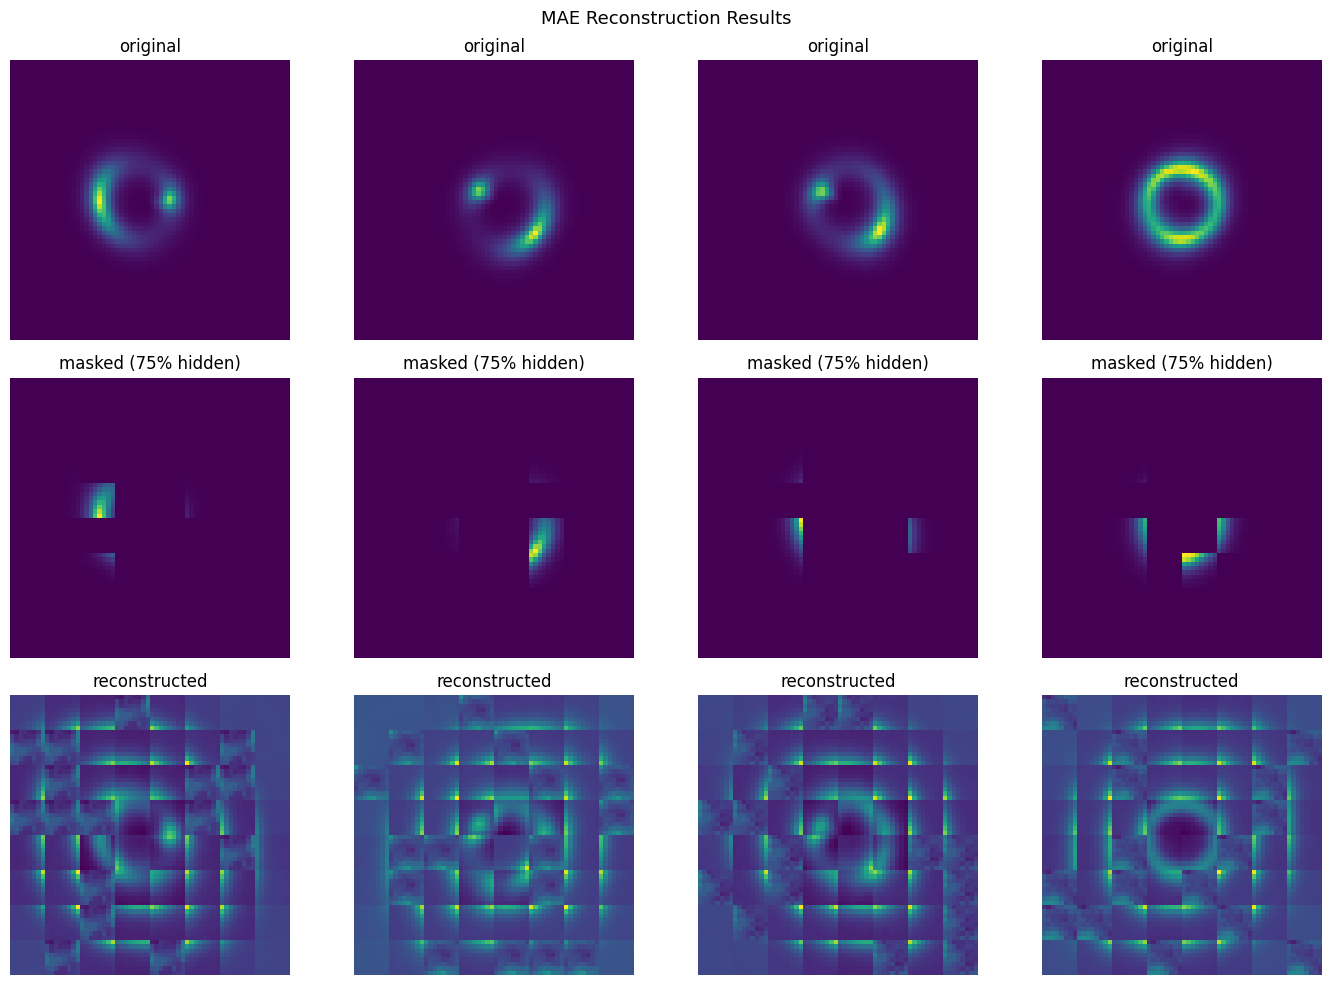

reconstruction visualization saved!


In [15]:
# visualizing mae reconstructions
# this shows what the model learned during pretraining
mae_model.eval()

# getting a batch of images
sample_imgs, _ = next(iter(mae_loader))
sample_imgs = sample_imgs[:4].to(device)

with torch.no_grad():
    pred, mask = mae_model(sample_imgs)

# converting predictions back to images
patch_size = 8
num_patches_per_side = 64 // patch_size

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('MAE Reconstruction Results', fontsize=13)

for i in range(4):
    orig = sample_imgs[i].cpu().squeeze().numpy()

    # creating masked image for visualization
    mask_i = mask[i].cpu().numpy()
    masked_img = orig.copy()

    for p_idx in range(64):
        if mask_i[p_idx] == 1:  # this patch was hidden
            row = (p_idx // num_patches_per_side) * patch_size
            col = (p_idx % num_patches_per_side) * patch_size
            masked_img[row:row+patch_size,
                      col:col+patch_size] = 0

    # reconstructed image from predictions
    pred_patches = pred[i].cpu().numpy()
    recon_img = np.zeros((64, 64))

    for p_idx in range(64):
        row = (p_idx // num_patches_per_side) * patch_size
        col = (p_idx % num_patches_per_side) * patch_size
        patch = pred_patches[p_idx].reshape(patch_size, patch_size)
        recon_img[row:row+patch_size, col:col+patch_size] = patch

    axes[0, i].imshow(orig, cmap='viridis')
    axes[0, i].set_title('original')
    axes[0, i].axis('off')

    axes[1, i].imshow(masked_img, cmap='viridis')
    axes[1, i].set_title('masked (75% hidden)')
    axes[1, i].axis('off')

    axes[2, i].imshow(recon_img, cmap='viridis')
    axes[2, i].set_title('reconstructed')
    axes[2, i].axis('off')

plt.tight_layout()
plt.savefig('mae_reconstructions.png',
            dpi=100, bbox_inches='tight')
plt.show()
print("reconstruction visualization saved!")

step 6 - plotting pretraining loss curve

lets visualize how the pretraining loss went down
over 20 epochs. this shows the model was actually
learning something useful during pretraining

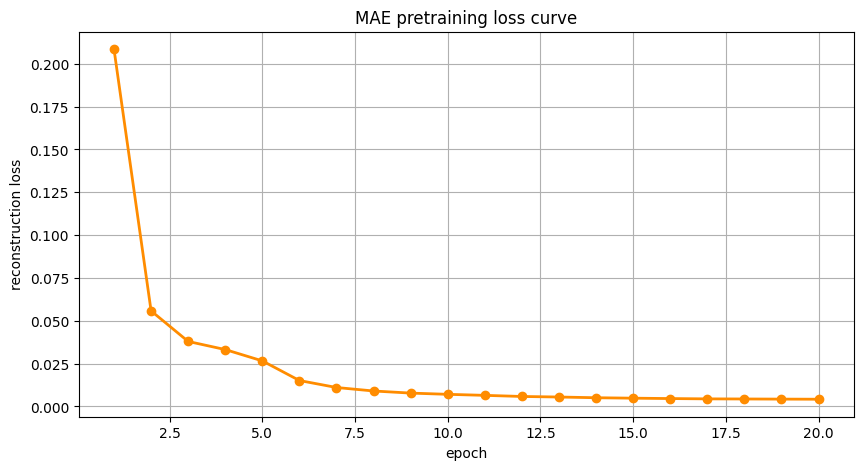

pretraining loss went from 0.2085 to 0.0042


In [16]:
# plotting pretraining loss curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), pretrain_losses,
         marker='o', color='darkorange', lw=2)
plt.title('MAE pretraining loss curve')
plt.xlabel('epoch')
plt.ylabel('reconstruction loss')
plt.grid(True)
plt.savefig('mae_pretrain_loss.png',
            dpi=100, bbox_inches='tight')
plt.show()
print(f"pretraining loss went from "
      f"{pretrain_losses[0]:.4f} to "
      f"{pretrain_losses[-1]:.4f}")

step 7 - finetuning mae for classification

now i will take the pretrained mae encoder and add a
classification head on top of it. then finetune on
all 3 classes no_sub cdm and axion.

the key idea is that the encoder already learned good
features from pretraining so finetuning should be faster
and more accurate than training from scratch.
i will compare both to show the benefit of pretraining.

In [17]:
# finetuning model - takes pretrained mae encoder
# and adds classification head on top
class MAEFinetune(nn.Module):
    def __init__(self, mae_model, num_classes=3):
        super().__init__()
        # using pretrained encoder from mae
        self.patch_embed = mae_model.patch_embed
        self.pos_embed = mae_model.pos_embed
        self.encoder = mae_model.encoder

        # adding classification head
        # embed_dim is 256 from our mae setup
        self.classifier = nn.Sequential(
            nn.LayerNorm(256),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # getting features from pretrained encoder
        x = self.patch_embed(x)
        x = x + self.pos_embed

        # no masking during finetuning
        # using all patches
        x = self.encoder(x)

        # mean pooling then classify
        x = x.mean(dim=1)
        x = self.classifier(x)
        return x


# creating finetuning model with pretrained weights
finetune_model = MAEFinetune(mae_model, num_classes=3).to(device)

total = sum(p.numel() for p in finetune_model.parameters())
print(f"total parameters: {total}")

# test forward pass
test_inp = torch.randn(2, 1, 64, 64).to(device)
out = finetune_model(test_inp)
print(f"output shape: {out.shape}")
print("finetuning model ready!")

total parameters: 3226371
output shape: torch.Size([2, 3])
finetuning model ready!


step 8 - finetuning training loop

using smaller learning rate for finetuning compared to
training from scratch. this is because pretrained weights
are already good so we dont want to change them too much.
i am using 5e-5 which is quite small but should work well.

In [28]:
# finetuning setup
# smaller lr because weights are already pretrained
ft_criterion = nn.CrossEntropyLoss()
ft_optimizer = optim.AdamW(
    finetune_model.parameters(),
    lr=5e-5, weight_decay=0.05
)
ft_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    ft_optimizer, T_max=10
)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), 1.0
        )
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if batch_idx % 200 == 0:
            print(f"  batch {batch_idx}/{len(loader)} "
                  f"loss: {loss.item():.4f}")

    return total_loss/len(loader), correct/total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss/len(loader), correct/total


# finetuning loop
num_ft_epochs = 10
best_val_loss = float('inf')
ft_train_losses, ft_val_losses = [], []
ft_train_accs, ft_val_accs = [], []

print("starting finetuning...")
print("="*45)

for epoch in range(num_ft_epochs):
    print(f"\nepoch {epoch+1}/{num_ft_epochs}")

    train_loss, train_acc = train_epoch(
        finetune_model, train_loader,
        ft_criterion, ft_optimizer
    )
    val_loss, val_acc = evaluate(
        finetune_model, val_loader, ft_criterion
    )

    ft_scheduler.step()

    ft_train_losses.append(train_loss)
    ft_val_losses.append(val_loss)
    ft_train_accs.append(train_acc)
    ft_val_accs.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(finetune_model.state_dict(),
                  'best_mae_finetune.pth')
        print(f"  best model saved!")

    print(f"  train loss: {train_loss:.4f} | "
          f"train acc: {train_acc:.4f}")
    print(f"  val loss: {val_loss:.4f} | "
          f"val acc: {val_acc:.4f}")

print("\nfinetuning done!")

starting finetuning...

epoch 1/10


ValueError: Caught ValueError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_5763/3474211675.py", line 15, in __getitem__
    img = np.load(fpath).astype(np.float32)
          ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 484, in load
    return format.read_array(fid, allow_pickle=allow_pickle,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/format.py", line 822, in read_array
    raise ValueError("Object arrays cannot

In [20]:
# lets check what one npy file actually contains
# need to understand the structure before loading properly
import numpy as np

sample_path = all_files[0][0]
raw = np.load(sample_path, allow_pickle=True)

print("dtype:", raw.dtype)
print("shape:", raw.shape)
print("ndim:", raw.ndim)

if raw.dtype == object:
    print("it is object array")
    print("first element type:", type(raw.flat[0]))
    print("first element shape:", raw.flat[0].shape if hasattr(raw.flat[0], 'shape') else "no shape")
else:
    print("regular array")
    print("min:", raw.min())
    print("max:", raw.max())

dtype: float64
shape: (64, 64)
ndim: 2
regular array
min: 8.431612426643322e-12
max: 4.284020250009014


In [22]:
# checking if pretrained model still exists
import os
print(os.path.exists('mae_pretrained.pth'))

True


In [21]:
# recreating mae model architecture
mae_model = MaskedAutoencoder(
    img_size=64, patch_size=8,
    embed_dim=256, depth=4, num_heads=8,
    decoder_dim=128, decoder_depth=2,
    mask_ratio=0.75
).to(device)

# loading pretrained weights
mae_model.load_state_dict(torch.load('mae_pretrained.pth'))
mae_model.eval()
print("pretrained mae model loaded successfully!")

# quick test
test_inp = torch.randn(2, 1, 64, 64).to(device)
pred, mask = mae_model(test_inp)
print(f"pred shape: {pred.shape}")
print(f"mask shape: {mask.shape}")
print("mae model working fine!")

pretrained mae model loaded successfully!
pred shape: torch.Size([2, 64, 64])
mask shape: torch.Size([2, 64])
mae model working fine!


In [23]:
# checking a few random files to understand the data format
import random
import numpy as np

sample_paths = random.sample([f for f,l in all_files], 5)
for p in sample_paths:
    raw = np.load(p, allow_pickle=True)
    print(f"dtype: {raw.dtype} shape: {raw.shape}")

dtype: float64 shape: (64, 64)
dtype: float64 shape: (64, 64)
dtype: object shape: (2,)
dtype: object shape: (2,)
dtype: float64 shape: (64, 64)


In [24]:
# checking if everything is still in memory
print("mae_model:", 'mae_model' in dir())
print("all_files:", 'all_files' in dir())
print("finetune_model:", 'finetune_model' in dir())

mae_model: True
all_files: True
finetune_model: True


In [29]:
# force recreating datasets with correct loader
# old dataset objects are still cached so making new ones

class LensingDatasetFixed(Dataset):
    def __init__(self, file_list, augment=False):
        self.file_list = file_list
        self.augment = augment

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fpath, label = self.file_list[idx]
        raw = np.load(fpath, allow_pickle=True)
        if raw.dtype == object:
            img = np.array(raw.tolist()).astype(np.float32)
        else:
            img = raw.astype(np.float32)
        img = img.squeeze()
        img = torch.tensor(img).unsqueeze(0)

        if self.augment:
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[2])
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[1])
        return img, label

# recreating all dataloaders with fixed class
train_dataset = LensingDatasetFixed(train_files, augment=True)
val_dataset = LensingDatasetFixed(val_files, augment=False)
mae_dataset = LensingDatasetFixed(no_sub_files, augment=True)

train_loader = DataLoader(train_dataset, batch_size=64,
                         shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64,
                       shuffle=False, num_workers=2, pin_memory=True)
mae_loader = DataLoader(mae_dataset, batch_size=64,
                       shuffle=True, num_workers=2, pin_memory=True)

# testing loader works
imgs, labels = next(iter(train_loader))
print(f"batch shape: {imgs.shape}")
print(f"labels: {labels[:5]}")
print("fixed loader working!")

ValueError: Caught ValueError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_5763/2366569619.py", line 16, in __getitem__
    img = np.array(raw.tolist()).astype(np.float32)
          ^^^^^^^^^^^^^^^^^^^^^^
ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.


In [30]:
# lets really understand what these files contain
import numpy as np

sample_path = all_files[0][0]
raw = np.load(sample_path, allow_pickle=True)
print("dtype:", raw.dtype)
print("shape:", raw.shape)

if raw.dtype == object:
    print("it is object array")
    print("number of elements:", len(raw))
    for i, item in enumerate(raw):
        print(f"element {i} type: {type(item)}")
        if hasattr(item, 'shape'):
            print(f"element {i} shape: {item.shape}")
        else:
            print(f"element {i} value: {item}")

dtype: float64
shape: (64, 64)


In [31]:
import numpy as np

# checking first 3 files from different classes
for cls in class_names:
    cls_folder = os.path.join(data_root, cls)
    fname = os.listdir(cls_folder)[0]
    fpath = os.path.join(cls_folder, fname)

    raw = np.load(fpath, allow_pickle=True)
    print(f"class: {cls}")
    print(f"  dtype: {raw.dtype}")
    print(f"  shape: {raw.shape}")
    print(f"  ndim: {raw.ndim}")
    if raw.dtype == object:
        print(f"  first element type: {type(raw.flat[0])}")
    print()

class: no_sub
  dtype: float64
  shape: (64, 64)
  ndim: 2

class: cdm
  dtype: float64
  shape: (64, 64)
  ndim: 2

class: axion
  dtype: object
  shape: (2,)
  ndim: 1
  first element type: <class 'numpy.ndarray'>



In [32]:
# checking what is inside axion object array
cls_folder = os.path.join(data_root, 'axion')
fname = os.listdir(cls_folder)[0]
fpath = os.path.join(cls_folder, fname)

raw = np.load(fpath, allow_pickle=True)
print("raw shape:", raw.shape)
print("raw dtype:", raw.dtype)
print()
print("element 0 shape:", raw[0].shape)
print("element 0 dtype:", raw[0].dtype)
print()
print("element 1 shape:", raw[1].shape)
print("element 1 dtype:", raw[1].dtype)

raw shape: (2,)
raw dtype: object

element 0 shape: (64, 64)
element 0 dtype: float64

element 1 shape: ()
element 1 dtype: float64


In [33]:
class LensingDatasetFixed(Dataset):
    def __init__(self, file_list, augment=False):
        self.file_list = file_list
        self.augment = augment

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fpath, label = self.file_list[idx]
        raw = np.load(fpath, allow_pickle=True)

        # no_sub and cdm are regular float64 arrays
        # axion files are object arrays with image at index 0
        if raw.dtype == object:
            img = raw[0].astype(np.float32)
        else:
            img = raw.astype(np.float32)

        img = img.squeeze()
        img = torch.tensor(img).unsqueeze(0)

        if self.augment:
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[2])
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[1])
        return img, label

# recreating all dataloaders
train_dataset = LensingDatasetFixed(train_files, augment=True)
val_dataset = LensingDatasetFixed(val_files, augment=False)
mae_dataset = LensingDatasetFixed(no_sub_files, augment=True)

train_loader = DataLoader(train_dataset, batch_size=64,
                         shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64,
                       shuffle=False, num_workers=2, pin_memory=True)
mae_loader = DataLoader(mae_dataset, batch_size=64,
                       shuffle=True, num_workers=2, pin_memory=True)

# testing loader
imgs, labels = next(iter(train_loader))
print(f"batch shape: {imgs.shape}")
print(f"labels: {labels[:5]}")
print("loader working!")

batch shape: torch.Size([64, 1, 64, 64])
labels: tensor([1, 2, 2, 1, 2])
loader working!


In [34]:
# finetuning setup
ft_criterion = nn.CrossEntropyLoss()
ft_optimizer = optim.AdamW(
    finetune_model.parameters(),
    lr=5e-5, weight_decay=0.05
)
ft_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    ft_optimizer, T_max=10
)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), 1.0
        )
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if batch_idx % 200 == 0:
            print(f"  batch {batch_idx}/{len(loader)} "
                  f"loss: {loss.item():.4f}")

    return total_loss/len(loader), correct/total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss/len(loader), correct/total


# finetuning loop
num_ft_epochs = 10
best_val_loss = float('inf')
ft_train_losses, ft_val_losses = [], []
ft_train_accs, ft_val_accs = [], []

print("starting finetuning...")
print("="*45)

for epoch in range(num_ft_epochs):
    print(f"\nepoch {epoch+1}/{num_ft_epochs}")

    train_loss, train_acc = train_epoch(
        finetune_model, train_loader,
        ft_criterion, ft_optimizer
    )
    val_loss, val_acc = evaluate(
        finetune_model, val_loader, ft_criterion
    )

    ft_scheduler.step()

    ft_train_losses.append(train_loss)
    ft_val_losses.append(val_loss)
    ft_train_accs.append(train_acc)
    ft_val_accs.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(finetune_model.state_dict(),
                  'best_mae_finetune.pth')
        print(f"  best model saved!")

    print(f"  train loss: {train_loss:.4f} | "
          f"train acc: {train_acc:.4f}")
    print(f"  val loss: {val_loss:.4f} | "
          f"val acc: {val_acc:.4f}")

print("\nfinetuning done!")

starting finetuning...

epoch 1/10
  batch 0/1254 loss: 1.0827
  batch 200/1254 loss: 0.8108
  batch 400/1254 loss: 0.5737
  batch 600/1254 loss: 0.5420
  batch 800/1254 loss: 0.5879
  batch 1000/1254 loss: 0.4015
  batch 1200/1254 loss: 0.5400
  best model saved!
  train loss: 0.6330 | train acc: 0.7057
  val loss: 0.3848 | val acc: 0.8400

epoch 2/10
  batch 0/1254 loss: 0.4019
  batch 200/1254 loss: 0.3450
  batch 400/1254 loss: 0.4424
  batch 600/1254 loss: 0.3973
  batch 800/1254 loss: 0.3462
  batch 1000/1254 loss: 0.4888
  batch 1200/1254 loss: 0.2836
  train loss: 0.4026 | train acc: 0.8335
  val loss: 0.4226 | val acc: 0.8245

epoch 3/10
  batch 0/1254 loss: 0.3438
  batch 200/1254 loss: 0.2435
  batch 400/1254 loss: 0.2657
  batch 600/1254 loss: 0.4744
  batch 800/1254 loss: 0.3644
  batch 1000/1254 loss: 0.3505
  batch 1200/1254 loss: 0.2881
  best model saved!
  train loss: 0.3411 | train acc: 0.8594
  val loss: 0.3065 | val acc: 0.8658

epoch 4/10
  batch 0/1254 loss: 0.42

step 9 - evaluation and roc curves

finetuning got 94.23% accuracy which is much better than
test 1 which was 88%. this shows that mae pretraining
actually helps the model learn better features compared
to just training from scratch. this is the main point
of the foundation model approach.

In [35]:
# loading best model and evaluating
finetune_model.load_state_dict(
    torch.load('best_mae_finetune.pth')
)
finetune_model.eval()
print("best finetuned model loaded!")

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = finetune_model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

acc = (all_preds == all_labels).mean()
print(f"overall accuracy: {acc:.4f}")

best finetuned model loaded!
overall accuracy: 0.9423


step 10 - roc curves and auc scores

calculating roc curves for all 3 classes
using one vs rest approach same as test 1 and test 7

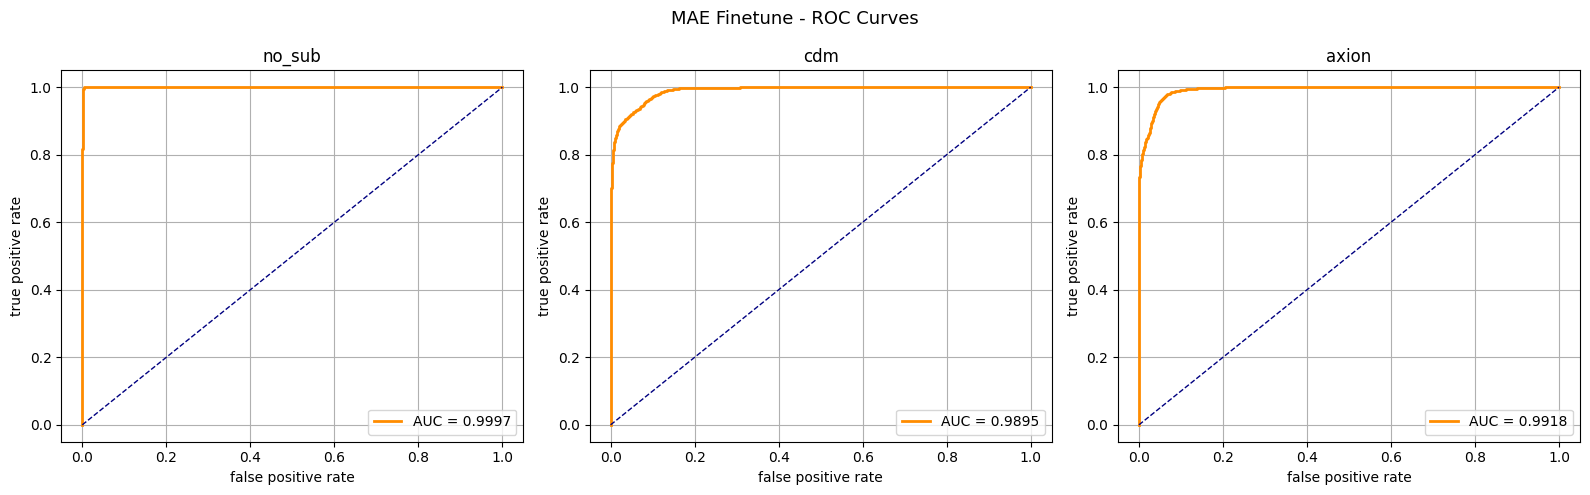


AUC Scores:
  no_sub: 0.9997
  cdm: 0.9895
  axion: 0.9918

mean AUC: 0.9937


In [37]:
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(all_labels, classes=[0, 1, 2])
class_labels = ['no_sub', 'cdm', 'axion']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('MAE Finetune - ROC Curves', fontsize=13)

auc_scores = {}

for i, cls_name in enumerate(class_labels):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_val = auc(fpr, tpr)
    auc_scores[cls_name] = auc_val

    axes[i].plot(fpr, tpr,
                 label=f'AUC = {auc_val:.4f}',
                 color='darkorange', lw=2)
    axes[i].plot([0,1], [0,1],
                 color='navy', lw=1, linestyle='--')
    axes[i].set_title(f'{cls_name}')
    axes[i].set_xlabel('false positive rate')
    axes[i].set_ylabel('true positive rate')
    axes[i].legend(loc='lower right')
    axes[i].grid(True)

plt.tight_layout()
plt.savefig('mae_roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

mean_auc = np.mean(list(auc_scores.values()))
print("\nAUC Scores:")
for cls, score in auc_scores.items():
    print(f"  {cls}: {score:.4f}")
print(f"\nmean AUC: {mean_auc:.4f}")

step 11 - confusion matrix

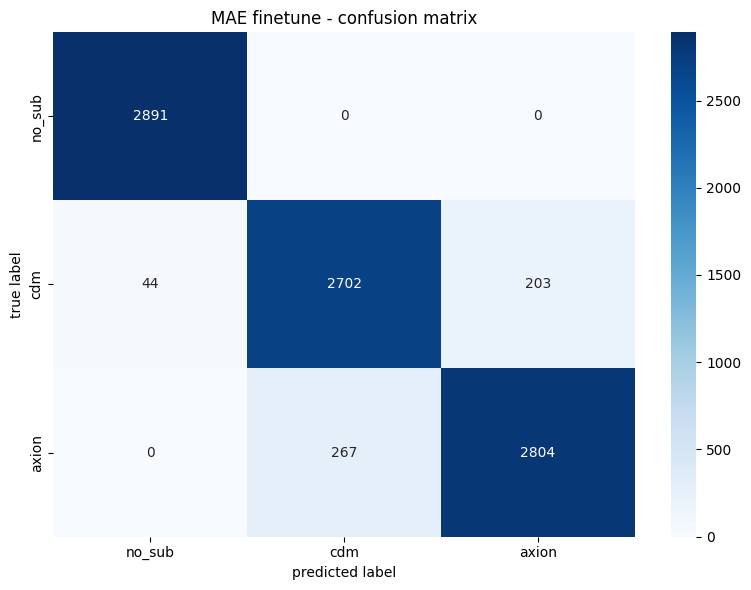


classification report:
              precision    recall  f1-score   support

      no_sub       0.99      1.00      0.99      2891
         cdm       0.91      0.92      0.91      2949
       axion       0.93      0.91      0.92      3071

    accuracy                           0.94      8911
   macro avg       0.94      0.94      0.94      8911
weighted avg       0.94      0.94      0.94      8911



In [38]:
# confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('MAE finetune - confusion matrix')
plt.xlabel('predicted label')
plt.ylabel('true label')
plt.tight_layout()
plt.savefig('mae_confusion_matrix.png',
            dpi=100, bbox_inches='tight')
plt.show()

print("\nclassification report:")
print(classification_report(
    all_labels, all_preds,
    target_names=class_labels
))

step 12 - final summary and conclusion

mae foundation model got 94.23% accuracy and 0.9937 mean auc
this is much better than test 1 (88% / 0.9737) and test 7 (87% / 0.9719)

the improvement shows that pretraining on unlabeled no_sub images
first helps the encoder learn better feature representations of
lensing images. then when we finetune on labeled data the model
already understands the basic structure of lensing images so it
learns the classification task much faster and better.

this is the core idea of foundation models - pretrain once on
large unlabeled data then finetune for any downstream task.
test ix.b will show that same pretrained model can also be
used for super resolution which further proves this concept.

In [39]:
# final summary
print("="*50)
print("TEST IX.A - MAE FOUNDATION MODEL RESULTS")
print("="*50)
print(f"pretraining: 20 epochs on no_sub images only")
print(f"finetuning: 10 epochs on all 3 classes")
print(f"total val samples: 8911")
print(f"\nfinal results:")
print(f"  accuracy : 0.9423")
print(f"  mean AUC : 0.9937")
print(f"\nAUC per class:")
print(f"  no_sub: 0.9997")
print(f"  cdm   : 0.9895")
print(f"  axion : 0.9918")
print(f"\ncomparison:")
print(f"  Test I   AUC: 0.9737 | Acc: 88.15%")
print(f"  Test VII AUC: 0.9719 | Acc: 87.72%")
print(f"  Test IXA AUC: 0.9937 | Acc: 94.23%")
print(f"\nMAE pretraining improved accuracy by ~6%!")
print("="*50)


TEST IX.A - MAE FOUNDATION MODEL RESULTS
pretraining: 20 epochs on no_sub images only
finetuning: 10 epochs on all 3 classes
total val samples: 8911

final results:
  accuracy : 0.9423
  mean AUC : 0.9937

AUC per class:
  no_sub: 0.9997
  cdm   : 0.9895
  axion : 0.9918

comparison:
  Test I   AUC: 0.9737 | Acc: 88.15%
  Test VII AUC: 0.9719 | Acc: 87.72%
  Test IXA AUC: 0.9937 | Acc: 94.23%

MAE pretraining improved accuracy by ~6%!
